In [54]:
import os
import time
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import keras_tuner as kt

In [3]:
try:
    tf.config.set_visible_devices([], 'GPU')
    visible_devices = tf.config.get_visible_devices()
    print(f"Using: {visible_devices}")
except Exception as e:
    print(e)

Using: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# Load the Dataset

In [4]:
def make_unique_labels(labels):
    seen = {}
    unique_labels = []
    
    for label in labels:
        if label not in seen:
            # First time seeing this label
            seen[label] = 1
            unique_labels.append(label)
        else:
            # Duplicate label found
            count = seen[label]
            new_label = f"{label}_{count}"
            unique_labels.append(new_label)
            seen[label] += 1
            
    return unique_labels

In [99]:
labels = pd.read_csv("activity_data/UCI HAR Dataset/features.txt", sep = ' ', header = None)

labels_list = labels[1].tolist()

labels_unique = make_unique_labels(labels_list)


training = pd.read_csv("activity_data/UCI HAR Dataset/train/X_train.txt", sep = r'\s+', header = None, names = labels_unique)

train_values = pd.read_csv("activity_data/UCI HAR Dataset/train/y_train.txt", sep = ' ', header = None)

training['Activity'] = train_values[0]

print(training.head())

training.shape

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

(7352, 562)

# Data Cleaning

### Feature Selection

In [6]:
# Create list of target substrings

target_substrings = [
    '-mean()',  # Mean value [cite: 9]
    '-std()',   # Standard deviation [cite: 9]
    'Mag-',     # Magnitude features (e.g., tBodyAccMag) [cite: 6]
    'angle('    # Angle features [cite: 12]
]

subset_labels = ['Activity']
for unique_label, original_label in zip(labels_unique, labels_list):
    # Check if any of the target substrings are present in the original label
    if any(sub in original_label for sub in target_substrings):
        subset_labels.append(unique_label)

len(subset_labels)

173

In [7]:
activity_subset = training[subset_labels]

print(activity_subset.shape)
activity_subset.head()

(7352, 173)


,Activity,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,0.963396,-0.140840,0.115375,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,0.966561,-0.141551,0.109379,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,0.966878,-0.142010,0.101884,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,0.967615,-0.143976,0.099850,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,0.968224,-0.148750,0.094486,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


# EDA

In [8]:
## Label each activity

activity_map = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

type_map = {
    1: 'Dynamic',
    2: 'Dynamic',
    3: 'Dynamic',
    4: 'Static',
    5: 'Static',
    6: 'Static'
}

activity_subset['Activity_label'] = activity_subset['Activity'].map(activity_map)
activity_subset['Activity_type'] = activity_subset['Activity'].map(type_map)

print(activity_subset['Activity_label'].value_counts())

Activity_label
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


/var/folders/cq/hlz4cmtx3wx6v9j1wc_j6b8n160k38/T/ipykernel_64402/3770891298.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activity_subset['Activity_label'] = activity_subset['Activity'].map(activity_map)
/var/folders/cq/hlz4cmtx3wx6v9j1wc_j6b8n160k38/T/ipykernel_64402/3770891298.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activity_subset['Activity_type'] = activity_subset['Activity'].map(type_map)


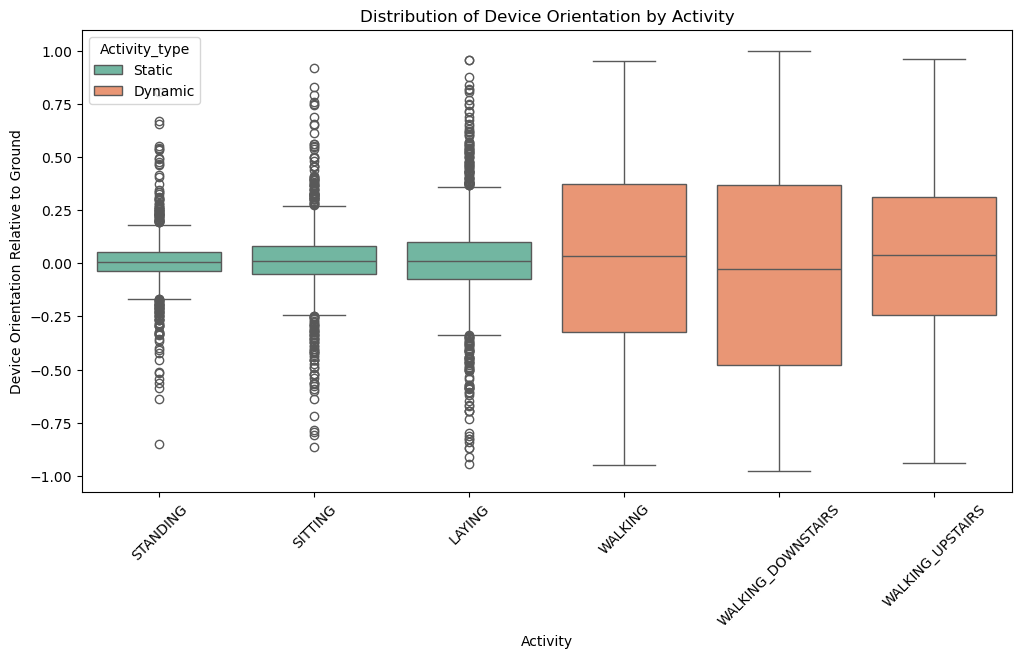

In [107]:
plt.figure(figsize=(12, 6))
# Choose a feature that represents 'intensity' or 'gravity'
sns.boxplot(x = 'Activity_label', y = 'angle(tBodyAccMean,gravity)', data = activity_subset, palette='Set2', hue = 'Activity_type')
plt.title('Distribution of Device Orientation by Activity')
plt.xticks(rotation=45)
plt.xlabel('Activity')
plt.ylabel('Device Orientation Relative to Ground')

plt.savefig('Activities_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

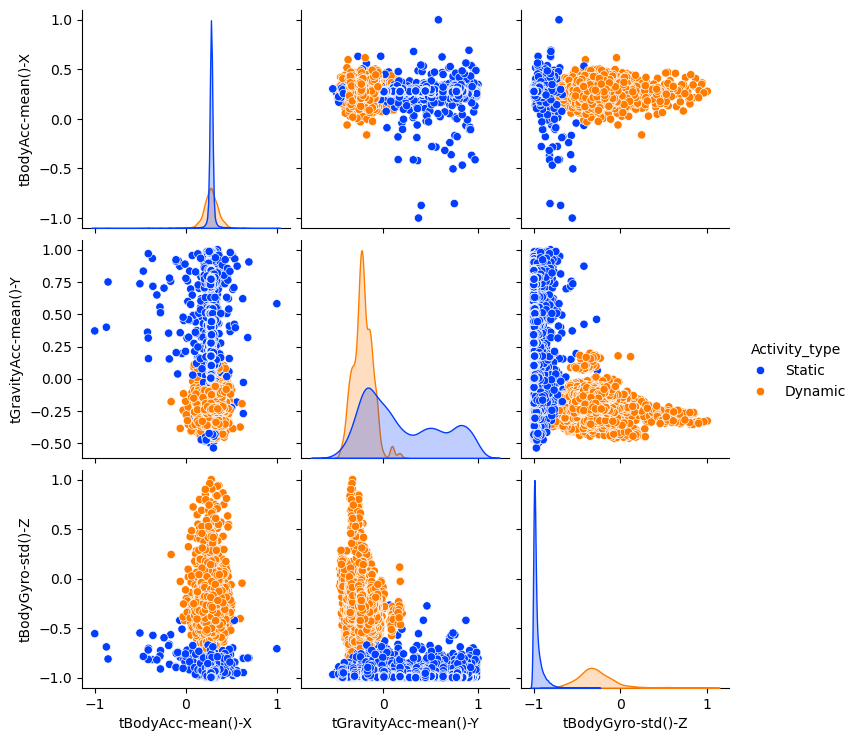

In [101]:
# Select a small subset of interesting features to avoid clutter
subset_features = ['tBodyAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tBodyGyro-std()-Z', 'Activity_type']

sns.pairplot(activity_subset[subset_features], hue='Activity_type', palette='bright')

plt.savefig('Static_vs_dynamic.png', dpi=300, bbox_inches='tight')

plt.show()

In [103]:
X = activity_subset.drop(['Activity', 'Activity_label', 'Activity_type'], axis=1)
y = activity_subset['Activity_label']

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X)

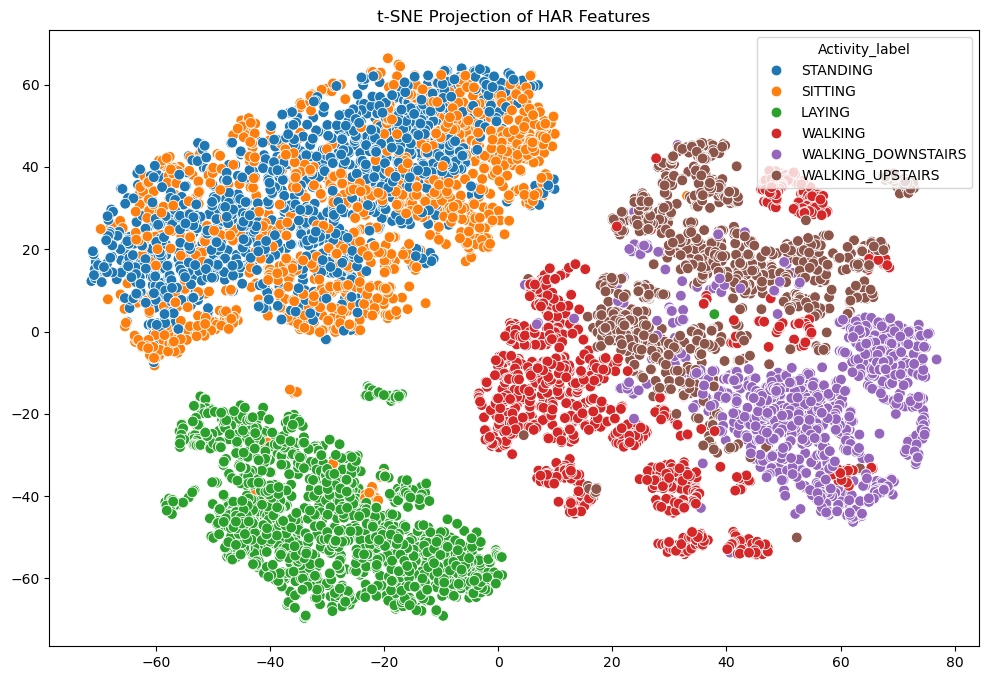

In [106]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y, s=60)
plt.title('t-SNE Projection of HAR Features')

plt.savefig('TSNE.png', dpi=300, bbox_inches='tight')

plt.show()

List of model types:
- Logistic Regression
- Random Forest
- SVM
- Gradient Boosting
- Neural Network

# Model Fitting

In [44]:
X = activity_subset.drop(['Activity', 'Activity_label', 'Activity_type'], axis = 1)
y = activity_subset['Activity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
y_train = y_train - 1
y_test = y_test - 1

### Logistic Regression

In [66]:
lr = LogisticRegression(max_iter=1000, solver='lbfgs')
start = time.time()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
end = time.time()

time_lr = end - start

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)
print("Time elapsed:", time_lr)

Accuracy: 0.9612508497620667
Time elapsed: 1.676900863647461


### Random Forest

In [67]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()

rfc.fit(X_train_scaled, y_train)

y_pred_rfc = rfc.predict(X_test_scaled)
end = time.time()

time_rfc = end - start

accuracy_rfc = accuracy_score(y_test, y_pred_rfc)

print("Accuracy:", accuracy_rfc)
print("Time elapsed:", time_rfc)

Accuracy: 0.972807613868117
Time elapsed: 3.721116304397583


### SVM (RBF kernel)

In [68]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
start = time.time()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
end = time.time()

time_svm = end - start

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Time elapsed:", time_svm)

Accuracy: 0.9490142760027193
Time elapsed: 0.747847318649292


### Gradient Boosting Classifier

In [69]:
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
start = time.time()

gbc.fit(X_train_scaled, y_train)

y_pred_gbc = gbc.predict(X_test_scaled)
end = time.time()

time_gbc = end - start

accuracy_gbc = accuracy_score(y_test, y_pred_gbc)

print("Accuracy:", accuracy_gbc)
print("Time elapsed:", time_gbc)

Accuracy: 0.981645139360979
Time elapsed: 144.30671882629395


### Histogram Gradient Boosting Classifier

In [70]:
hgbc = HistGradientBoostingClassifier(learning_rate=0.1, random_state=42)
start = time.time()

hgbc.fit(X_train_scaled, y_train)

y_pred_hgbc = hgbc.predict(X_test_scaled)
end = time.time()

time_hgbc = end - start

accuracy_hgbc = accuracy_score(y_test, y_pred_hgbc)

print("Accuracy:", accuracy_hgbc)
print("Time elapsed:", time_hgbc)

Accuracy: 0.9884432358939497
Time elapsed: 4.531441926956177


### MLP Classifier

In [71]:
n_features = X_train_scaled.shape[1]

In [72]:
mlp = Sequential([
    # Input Layer (matches number of features)
    # Dense(64) means 64 neurons in the first hidden layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Dropout helps prevent overfitting by randomly turning off neurons
    Dropout(0.2),
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    
    # Output Layer
    # Must match 'num_classes' (6) and use 'softmax' for probability distribution
    Dense(6, activation='softmax')
])

start = time.time()
mlp.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = mlp.fit(
    X_train_scaled, y_train,
    epochs=50,           # How many times to see the dataset
    batch_size=32,       # Update weights after every 32 samples
    validation_split=0.2, # Use 20% of training data to validate during training
    verbose=0
)

loss, accuracy_mlp = mlp.evaluate(X_test_scaled, y_test, verbose=0)
end = time.time()

time_mlp = end - start

print("Accuracy:", accuracy_mlp)
print("Time elapsed:", time_mlp)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.9530931115150452
Time elapsed: 5.751174211502075


# Accuracy

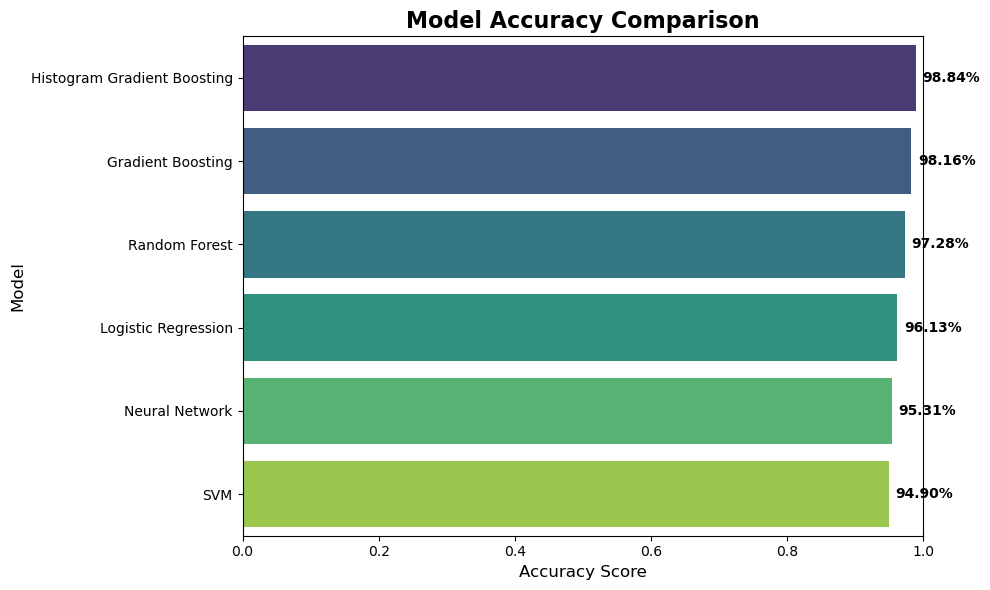

In [137]:
model_scores = {
    "Logistic Regression": accuracy_lr,
    "Random Forest": accuracy_rfc,
    "SVM": accuracy_svm,
    "Gradient Boosting": accuracy_gbc,
    "Neural Network": accuracy_mlp,
    "Histogram Gradient Boosting": accuracy_hgbc
}


df_acc = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy'])

df_acc = df_acc.sort_values(by='Accuracy', ascending=False)

df_acc['Type'] = 'All Features'

plt.figure(figsize=(10, 6))

# Create bar plot
# palette='viridis' gives a nice gradient color
# hue='Model' and legend=False are used to avoid a future warning in Seaborn
ax = sns.barplot(x='Accuracy', y='Model', data=df_acc, hue='Model', palette='viridis', legend=False)

# 3. Add Labels and Titles
plt.xlim(0, 1.0) # Accuracies are between 0 and 1
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Model', fontsize=12)

# 4. Add the actual numbers on the bars (Annotations)
for i, v in enumerate(df_acc['Accuracy']):
    # Place text slightly inside the bar or to the right
    ax.text(v + 0.01, i, f"{v:.2%}", color='black', va='center', fontweight='bold')

# Show the plot
plt.tight_layout()

plt.savefig('model_acc.png', dpi=300, bbox_inches='tight')

plt.show()

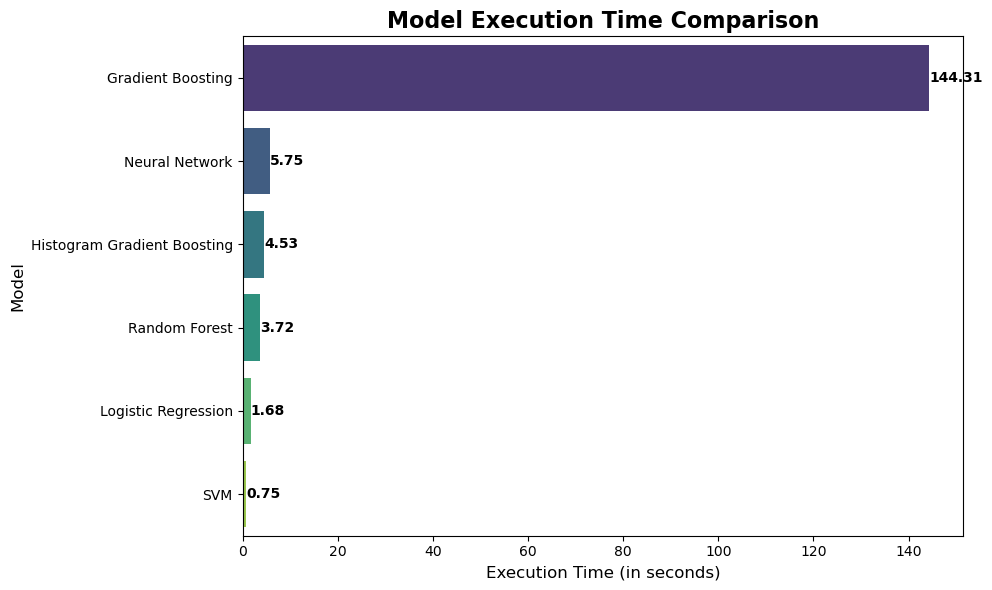

In [162]:
model_times = {
    "Logistic Regression": time_lr,
    "Random Forest": time_rfc,
    "SVM": time_svm,
    "Gradient Boosting": time_gbc,
    "Neural Network": time_mlp,
    "Histogram Gradient Boosting": time_hgbc
}


df_times = pd.DataFrame(list(model_times.items()), columns=['Model', 'Time'])

df_times = df_times.sort_values(by='Time', ascending=False)

df_times['Type'] = "All Features"

plt.figure(figsize=(10, 6))

# Create bar plot
# palette='viridis' gives a nice gradient color
# hue='Model' and legend=False are used to avoid a future warning in Seaborn
ax = sns.barplot(x='Time', y='Model', data=df_times, hue='Model', palette='viridis', legend=False)

# 3. Add Labels and Titles
plt.title('Model Execution Time Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Execution Time (in seconds)', fontsize=12)
plt.ylabel('Model', fontsize=12)

# 4. Add the actual numbers on the bars (Annotations)
for i, v in enumerate(df_times['Time']):
    # Place text slightly inside the bar or to the right
    ax.text(v + 0.01, i, f"{v:.2f}", color='black', va='center', fontweight='bold')

# Show the plot
plt.tight_layout()

plt.savefig('model_time.png', dpi=300, bbox_inches='tight')

plt.show()

In [75]:
# Create a Comparison DataFrame
comparison = pd.DataFrame({
    'Truth (y_test)': y_test[:20],  # Look at first 20 rows
    'Prediction (y_pred)': y_pred[:20]
})

print(comparison)
print("\nUnique values in Truth:", sorted(set(y_test)))
print("Unique values in Preds:", sorted(set(y_pred)))

      Truth (y_test)  Prediction (y_pred)
3549               0                    4
5608               0                    4
5342               5                    3
5450               1                    4
3749               0                    0
5064               1                    3
659                2                    4
6136               5                    3
417                5                    3
7283               0                    3
5073               4                    3
3272               4                    3
729                3                    3
6179               0                    4
5934               3                    3
4865               2                    0
5924               3                    3
4212               4                    4
5495               4                    3
5059               1                    4

Unique values in Truth: [0, 1, 2, 3, 4, 5]
Unique values in Preds: [0, 1, 2, 3, 4, 5]


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step


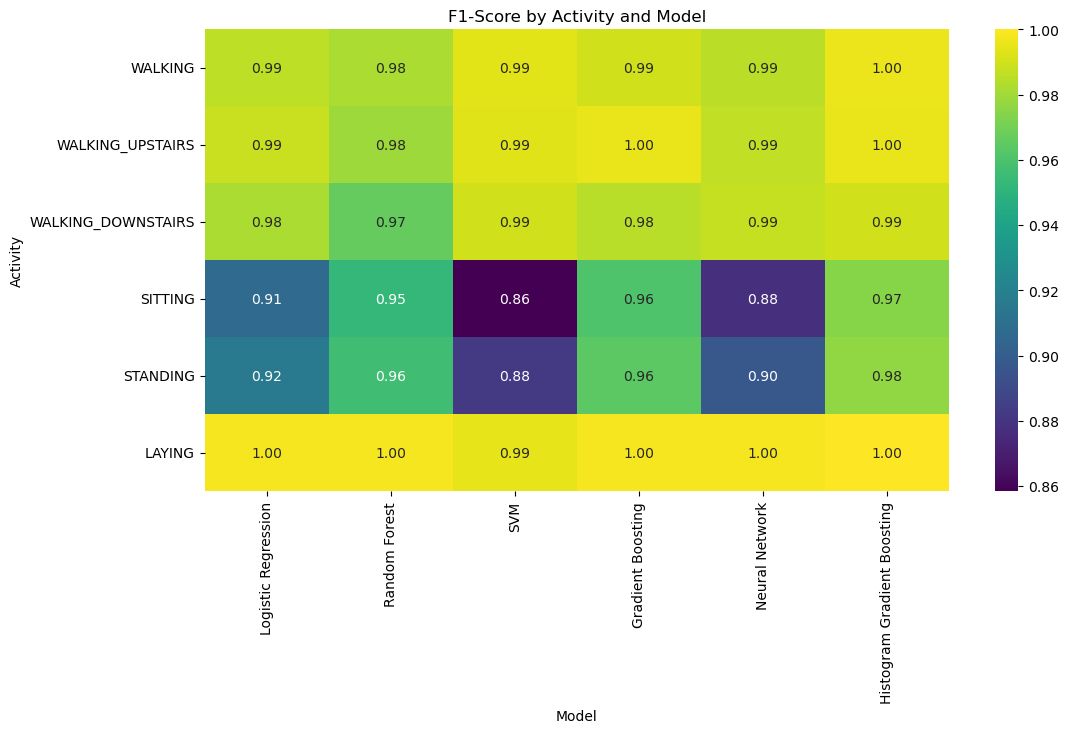

In [122]:
# 1. Initialize a dictionary to store scores
activity_scores = {}
models = {
    "Logistic Regression": lr,
    "Random Forest": rfc,
    "SVM": svm,
    "Gradient Boosting": gbc,
    "Neural Network": mlp,
    "Histogram Gradient Boosting": hgbc
}

correct_labels = [
    'WALKING',             # 0
    'WALKING_UPSTAIRS',    # 1
    'WALKING_DOWNSTAIRS',  # 2
    'SITTING',             # 3
    'STANDING',            # 4
    'LAYING'               # 5
]

# 2. Loop through all your trained models
# Assuming 'models' dict contains your trained models (LR, RF, SVM, etc.)
# and you are using the final feature set (X_train_final, X_test_final)

for name, model in models.items():
    # Predict
    y_pred = model.predict(X_test_scaled)

    if y_pred.ndim > 1:
        # Take the index of the highest probability to get the class label (0-5)
        y_pred = np.argmax(y_pred, axis=1)
    # Calculate F1 score for EACH class (activity)
    # average=None returns the score for each class individually
    f1_by_class = f1_score(y_test, y_pred, average=None, labels = [0,1,2,3,4,5])
    
    # Store it
    activity_scores[name] = f1_by_class

# 3. Convert to DataFrame for easy plotting
df_activity_scores = pd.DataFrame(activity_scores, index=correct_labels)

# 4. Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_activity_scores, annot=True, cmap='viridis', fmt=".2f")
plt.title('F1-Score by Activity and Model')
plt.ylabel('Activity')
plt.xlabel('Model')

plt.savefig('F1_scores.png', dpi=300, bbox_inches='tight')

plt.show()

### On execution times

GBC shows by far the highest computation time, which is likely because it builds decision trees sequentially (as opposed to in parallel, as RFC does). Additionally, since this is running on the cpu (and only uses 1 cpu core), the execution time is very high.

## Further Feature Reduction

### While the features have already been reduced from the original dataset, I wanted to see if I could further reduce the features to lower execution time and remove redundancy

### Correlation Analysis

In [16]:
X_labels = [label for label in subset_labels if label != 'Activity']
X_temp = pd.DataFrame(X_train_scaled, columns=X_labels) 
corr_matrix = X_temp.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Dropping {len(to_drop)} highly correlated features.")
print(to_drop[:5]) # Show first 5 names

# Drop them
X_train_reduced = X_temp.drop(columns=to_drop)
X_test_reduced = pd.DataFrame(X_test_scaled, columns=X_labels).drop(columns=to_drop)

reduced_labels = X_train_reduced.columns.tolist()

print(X_train_reduced.shape)

Dropping 101 highly correlated features.
['tBodyAccJerk-std()-X', 'tBodyAccJerk-std()-Y', 'tBodyGyroJerk-std()-X', 'tBodyAccMag-mean()', 'tBodyAccMag-std()']
(5881, 71)


### Importance via Random Forest Feature Importance

/var/folders/cq/hlz4cmtx3wx6v9j1wc_j6b8n160k38/T/ipykernel_64402/3967527680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')


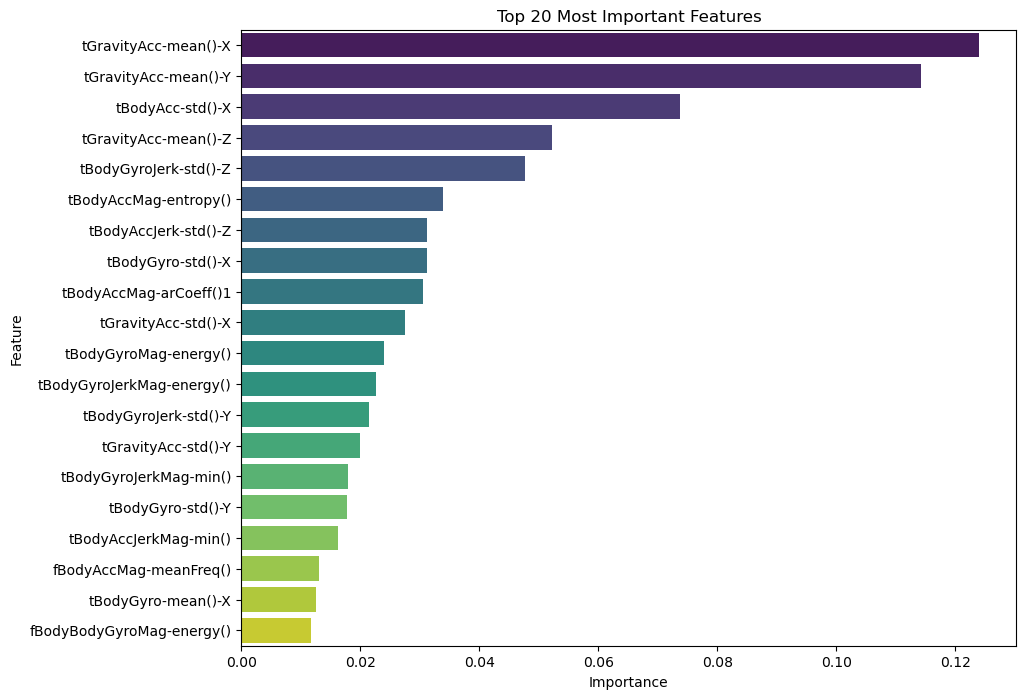

Selected 23 features.


In [123]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_reduced, y_train)

importances = rf_selector.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': reduced_labels,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(20), palette='viridis')
plt.title('Top 20 Most Important Features')

plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

selected_feats = feature_imp_df[feature_imp_df['Importance'] > 0.01]['Feature'].tolist()
print(f"Selected {len(selected_feats)} features.")

## Re-fitting the Models

In [80]:
X2 = activity_subset[selected_feats]
y2 = activity_subset['Activity']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size = 0.2, random_state = 42, stratify = y2
)

In [81]:
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

In [82]:
y_train2 = y_train2 - 1
y_test2 = y_test2 - 1

In [83]:
lr2 = LogisticRegression(max_iter=1000, solver='lbfgs')
start = time.time()

lr2.fit(X_train_scaled2, y_train2)

y_pred_lr2 = lr2.predict(X_test_scaled2)
end = time.time()

time_lr2 = end - start

accuracy_lr2 = accuracy_score(y_test2, y_pred_lr2)

print("Accuracy:", accuracy_lr2)
print("Time elapsed:", time_lr2)

Accuracy: 0.9374575118966689
Time elapsed: 0.5331149101257324


In [84]:
rfc2 = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()

rfc2.fit(X_train_scaled2, y_train2)

y_pred_rfc2 = rfc2.predict(X_test_scaled2)
end = time.time()

time_rfc2 = end - start

accuracy_rfc2 = accuracy_score(y_test2, y_pred_rfc2)

print("Accuracy:", accuracy_rfc2)
print("Time elapsed:", time_rfc2)

Accuracy: 0.9721278042148198
Time elapsed: 1.2475378513336182


In [85]:
svm2 = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
start = time.time()

svm2.fit(X_train_scaled2, y_train2)

y_pred_svm2 = svm2.predict(X_test_scaled2)
end = time.time()

time_svm2 = end - start

accuracy_svm2 = accuracy_score(y_test2, y_pred_svm2)

print("Accuracy:", accuracy_svm2)
print("Time elapsed:", time_svm2)

Accuracy: 0.9415363698164514
Time elapsed: 0.35891008377075195


In [86]:
gbc2 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
start = time.time()

gbc2.fit(X_train_scaled2, y_train2)

y_pred_gbc2 = gbc2.predict(X_test_scaled2)
end = time.time()

time_gbc2 = end - start

accuracy_gbc2 = accuracy_score(y_test2, y_pred_gbc2)

print("Accuracy:", accuracy_gbc2)
print("Time elapsed:", time_gbc2)

Accuracy: 0.973487423521414
Time elapsed: 20.05683398246765


In [87]:
hgbc2 = HistGradientBoostingClassifier(learning_rate=0.1, random_state=42)
start = time.time()

hgbc2.fit(X_train_scaled2, y_train2)

y_pred_hgbc2 = hgbc2.predict(X_test_scaled2)
end = time.time()

time_hgbc2 = end - start

accuracy_hgbc2 = accuracy_score(y_test2, y_pred_hgbc2)

print("Accuracy:", accuracy_hgbc2)
print("Time elapsed:", time_hgbc2)

Accuracy: 0.9830047586675731
Time elapsed: 3.424121141433716


In [88]:
n_features2 = X_train_scaled2.shape[1]

In [90]:
mlp2 = Sequential([
    # Input Layer (matches number of features)
    # Dense(64) means 64 neurons in the first hidden layer
    Dense(64, activation='relu', input_shape=(X_train_scaled2.shape[1],)),
    
    # Dropout helps prevent overfitting by randomly turning off neurons
    Dropout(0.2),
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    
    # Output Layer
    # Must match 'num_classes' (6) and use 'softmax' for probability distribution
    Dense(6, activation='softmax')
])

start = time.time()
mlp2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history2 = mlp2.fit(
    X_train_scaled2, y_train2,
    epochs=50,           # How many times to see the dataset
    batch_size=32,       # Update weights after every 32 samples
    validation_split=0.2, # Use 20% of training data to validate during training
    verbose=0
)

loss2, accuracy_mlp2 = mlp2.evaluate(X_test_scaled2, y_test2, verbose=0)
end = time.time()

time_mlp2 = end - start

print("Accuracy:", accuracy_mlp2)
print("Time elapsed:", time_mlp2)

Accuracy: 0.9524133205413818
Time elapsed: 5.633640766143799


## Hyperparameter Tuning

In [91]:
# 1. Define the Model-Building Function
def build_model(hp):
    model_opt = Sequential()
    
    # Tuning the number of units in the first layer
    # We ask it to try values between 32 and 128, in steps of 32
    hp_units = hp.Int('units', min_value=32, max_value=128, step=32)
    model_opt.add(Dense(units=hp_units, activation='relu', input_shape=(X_train_scaled2.shape[1],)))
    
    # Tuning Dropout rate (0.1, 0.2, or 0.3)
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)
    model_opt.add(Dropout(hp_dropout))
    
    model_opt.add(Dense(32, activation='relu'))
    
    # Output Layer (Fixed at 6 classes)
    model_opt.add(Dense(6, activation='softmax'))
    
    # Tuning the Learning Rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model_opt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model_opt


In [93]:
# 2. Initialize the Tuner (We use Hyperband - it's fast and efficient)
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='model_optimization',
    project_name='har_tuning'
)

# 3. Stop early if validation accuracy doesn't improve
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# 4. Run the Search
print("Starting Hyperparameter Search...")
tuner.search(X_train_scaled2, y_train2, epochs=20, validation_split=0.2, callbacks=[stop_early])

# 5. Get the Best Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. 
The optimal number of units in the first dense layer is {best_hps.get('units')}.
The optimal dropout rate is {best_hps.get('dropout')}.
The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

# 6. Build the Final Model with these best settings
best_model = tuner.hypermodel.build(best_hps)

Reloading Tuner from model_optimization/har_tuning/tuner0.json
Starting Hyperparameter Search...

The hyperparameter search is complete. 
The optimal number of units in the first dense layer is 64.
The optimal dropout rate is 0.2.
The optimal learning rate for the optimizer is 0.01.



In [95]:
start = time.time()

history_opt = best_model.fit(X_train_scaled2, y_train2, epochs=50, validation_split=0.2, verbose = 0)

loss_opt, accuracy_mlp_opt = best_model.evaluate(X_test_scaled2, y_test2, verbose=0)

end = time.time()

time_mlp_opt = end - start

print("Accuracy:", accuracy_mlp_opt)
print("Time elapsed:", time_mlp_opt)

Accuracy: 0.9537729620933533
Time elapsed: 5.061654090881348


## Accuracy (After feature reduction)

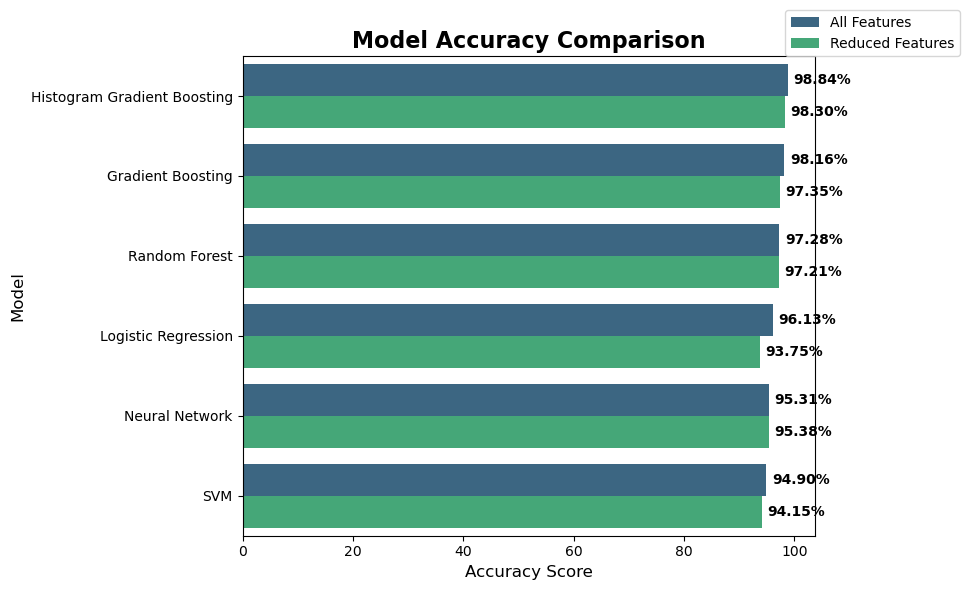

In [176]:
model_scores2 = {
    "Logistic Regression": accuracy_lr2,
    "Random Forest": accuracy_rfc2,
    "SVM": accuracy_svm2,
    "Gradient Boosting": accuracy_gbc2,
    "Neural Network": accuracy_mlp_opt,
    "Histogram Gradient Boosting": accuracy_hgbc2
}

df_acc2 = pd.DataFrame(list(model_scores2.items()), columns=['Model', 'Accuracy'])

df_acc2 = df_acc2.sort_values(by='Accuracy', ascending=False)

df_acc2['Type'] = 'Reduced Features'

df_combined = pd.concat([df_acc, df_acc2], axis=0)

df_combined['Accuracy'] = df_combined['Accuracy'] * 100

plt.figure(figsize=(10, 6))

# Create bar plot
# palette='viridis' gives a nice gradient color
# hue='Model' and legend=False are used to avoid a future warning in Seaborn
ax = sns.barplot(x='Accuracy', y='Model', data=df_combined, hue='Type', palette='viridis', legend=True)

plt.legend(title='', bbox_to_anchor=(1.1, 1), loc='lower center', borderaxespad=0)

# 3. Add Labels and Titles
#plt.xlim(0, 1.0) # Accuracies are between 0 and 1
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Model', fontsize=12)

# 4. Add the actual numbers on the bars (Annotations)
#for i, v in enumerate(df_combined['Accuracy']):
    # Place text slightly inside the bar or to the right
    #ax.text(v + 0.01, i, f"{v:.2%}", color='black', va='center', fontweight='bold')

for container in ax.containers:
    # fmt='%.2f%%' -> Formats 98.843 into "98.84%"
    ax.bar_label(container, fmt='%.2f%%', padding=4, fontweight='bold', fontsize=10)

# Show the plot
plt.tight_layout()

plt.savefig('accuracy_2.png', dpi=300, bbox_inches='tight')

plt.show()

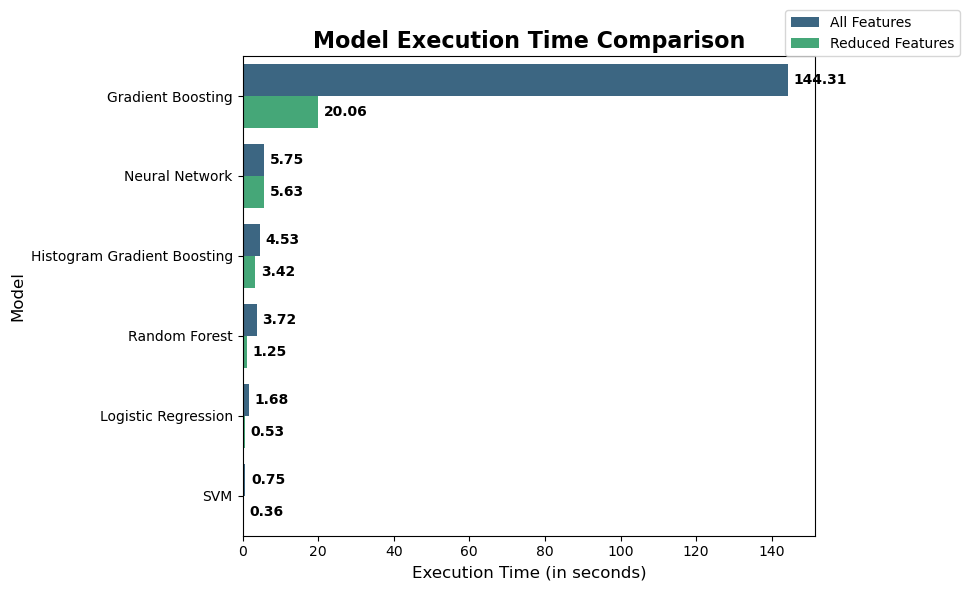

In [177]:
model_times2 = {
    "Logistic Regression": time_lr2,
    "Random Forest": time_rfc2,
    "SVM": time_svm2,
    "Gradient Boosting": time_gbc2,
    "Neural Network": time_mlp2,
    "Histogram Gradient Boosting": time_hgbc2
}


df_times2 = pd.DataFrame(list(model_times2.items()), columns=['Model', 'Time'])

df_times2 = df_times2.sort_values(by='Time', ascending=False)

df_times2['Type'] = "Reduced Features"

df_combined_times = pd.concat([df_times, df_times2], axis=0)

plt.figure(figsize=(10, 6))

# Create bar plot
# palette='viridis' gives a nice gradient color
# hue='Model' and legend=False are used to avoid a future warning in Seaborn
ax = sns.barplot(x='Time', y='Model', data=df_combined_times, hue='Type', palette='viridis', legend=True)

plt.legend(title='', bbox_to_anchor=(1.1, 1), loc='lower center', borderaxespad=0)

# 3. Add Labels and Titles
plt.title('Model Execution Time Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Execution Time (in seconds)', fontsize=12)
plt.ylabel('Model', fontsize=12)

for container in ax.containers:
    # fmt='%.2f%%' -> Formats 98.843 into "98.84%"
    ax.bar_label(container, fmt='%.2f', padding=4, fontweight='bold', fontsize=10)


# Show the plot
plt.tight_layout()

plt.savefig('model_time2.png', dpi=300, bbox_inches='tight')

plt.show()

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step


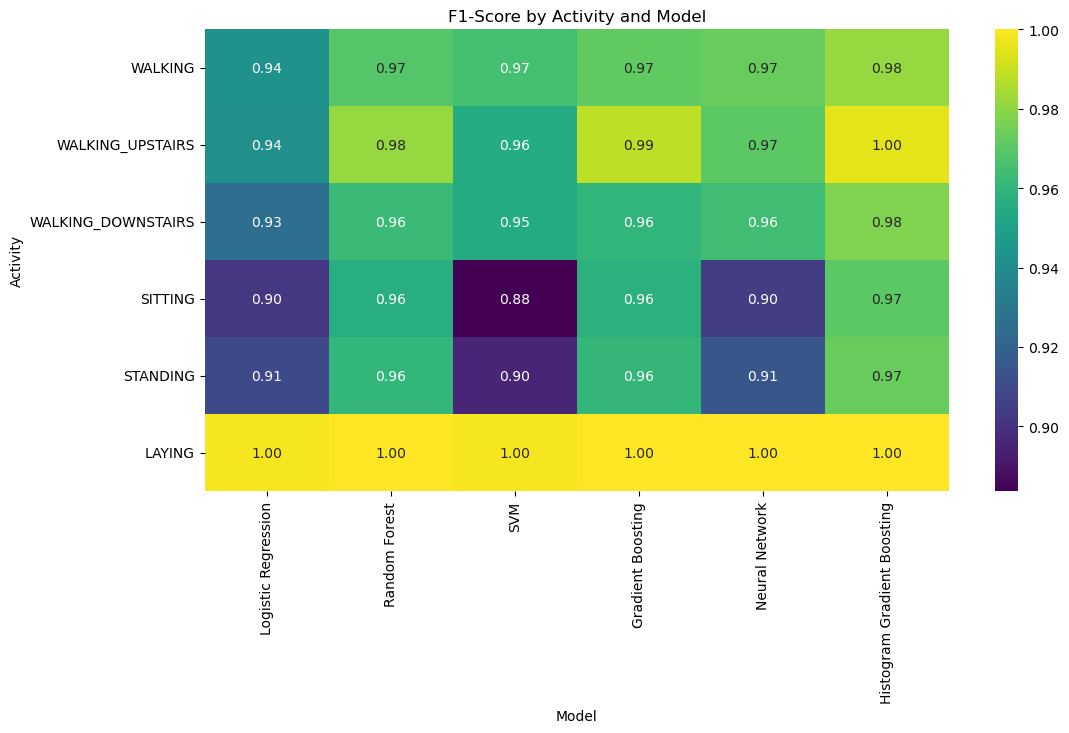

In [125]:
# 1. Initialize a dictionary to store scores
activity_scores = {}
models2 = {
    "Logistic Regression": lr2,
    "Random Forest": rfc2,
    "SVM": svm2,
    "Gradient Boosting": gbc2,
    "Neural Network": best_model,
    "Histogram Gradient Boosting": hgbc2
}

# 2. Loop through all your trained models
# Assuming 'models' dict contains your trained models (LR, RF, SVM, etc.)
# and you are using the final feature set (X_train_final, X_test_final)

for name, model in models2.items():
    # Predict
    y_pred = model.predict(X_test_scaled2)

    if y_pred.ndim > 1:
        # Take the index of the highest probability to get the class label (0-5)
        y_pred = np.argmax(y_pred, axis=1)
    # Calculate F1 score for EACH class (activity)
    # average=None returns the score for each class individually
    f1_by_class = f1_score(y_test2, y_pred, average=None, labels = [0,1,2,3,4,5])
    
    # Store it
    activity_scores[name] = f1_by_class

# 3. Convert to DataFrame for easy plotting
df_activity_scores = pd.DataFrame(activity_scores, index=correct_labels)

# 4. Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_activity_scores, annot=True, cmap='viridis', fmt=".2f")
plt.title('F1-Score by Activity and Model')
plt.ylabel('Activity')
plt.xlabel('Model')

plt.savefig('F1_scores_2.png', dpi=300, bbox_inches='tight')

plt.show()